# `08_codegradation_and_abstention.ipynb` — why reweighting can't rescue the bad regime, and what to do instead

The real-subset test settled the core question. Splitting windows by cECG quality gave two regimes:
clean-cECG ≈ 0.92 AUC, worst-10%-cECG ≈ 0.69 — a ~0.23 gap that proves the bad channel is where the
performance is actually lost. But on that bad subset the quality-weighted fusion recovered essentially
nothing (mean 0.690, SQI-weighted 0.689, gate 0.700). This notebook explains *why* with two analyses, both
on real data you already have:

1. **Co-degradation check** — show that when cECG is bad, PPG and BCG are usually bad *too*. If artifacts
   co-occur across the contactless modalities, then "route around the dead channel" fails because there is
   no clean channel left to route to. That turns the null result into a mechanism, not a mystery.
2. **Abstention / risk-coverage** — the honest use of the quality index when routing has nothing to route
   to: let the system *decline to decide* on windows where every channel is poor, and report AUC on the
   windows it does decide plus the coverage. Clinically this is "signal too poor to assess," and it is the
   natural job for the quality index here.

Self-contained (same setup + synthetic fallback as `07`); point Section 1 at your data for the real numbers.

## 1 · Setup + data + experts + per-modality composite SQI + fusion rules (as in `07`)

In [1]:
import warnings; warnings.filterwarnings("ignore")
import sys, os
import numpy as np, pandas as pd, matplotlib.pyplot as plt

os.chdir('/home/nik/projects/BA')

REPO_SRC, DATA_ROOT = "src/", "data/patients"
AF_LIST, RESULTS_DIR = "data/AF_patients.txt", "results/08"
FS, WINDOW_SEC, HOP_SEC, BCG_MODE, RANDOM_STATE = 128, 30, 15, "wavelet", 0
EXCLUDE_PATIENTS = []
MODALITIES = ["cecg", "ppg", "bcg"]
SIG_OF = {"cecg": ["cecg"], "ppg": ["ppg1", "ppg2"], "bcg": ["bcg1", "bcg2"]}
BAD_Q = 0.10          # "bad" = lowest this quantile of a channel's composite SQI
os.makedirs(RESULTS_DIR, exist_ok=True); sys.path.append(REPO_SRC)

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import roc_auc_score

try:
    import extract as X; HAVE_REPO = True
except Exception as e:
    HAVE_REPO = False; print("repo src not importable ->", e)

def synthetic_pipeline(n_pat=40, win=40, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    rows, groups, ys = [], [], []
    for pid in range(n_pat):
        for w in range(win):
            rows.append(f"PAT{pid:03d}"); groups.append(pid); ys.append(pid % 2)
    N = len(ys); yv = np.array(ys)
    base = rng.uniform(0, 1, N)                                   # shared per-window cleanliness
    qual = np.clip(0.6*base[:, None] + 0.4*rng.uniform(0, 1, (N, 3)), 0, 1)  # correlated degradation
    data = {"patient": rows, "win_idx": np.tile(np.arange(win), n_pat), "AF": yv.astype(float),
            "y": yv.astype(float)}
    for j, m in enumerate(MODALITIES):
        for s in SIG_OF[m]:
            for k in ["kSQI","sSQI","pSQI","bSQI","tSQI"]:
                col = qual[:, j] + 0.25*rng.standard_normal(N); col[rng.random(N) < 0.04] = np.nan
                data[f"sqi_{s}_{k}"] = np.clip(col, 0, 1)
            data[f"sqi_{s}_composite"] = np.clip(qual[:, j] + 0.12*rng.standard_normal(N), 0, 1)
    lab = pd.DataFrame(data)
    sqi_all = [c for c in lab.columns if c.startswith("sqi_") and not c.endswith("_composite")]
    lab.attrs["_qual"] = qual
    return lab, sqi_all, {m: [] for m in MODALITIES}

if HAVE_REPO and os.path.exists(DATA_ROOT):
    cfg = X.ExtractConfig(data_root=DATA_ROOT, af_list=AF_LIST, fs=FS, window_s=WINDOW_SEC,
                          hop_s=HOP_SEC, bcg_mode=BCG_MODE, min_valid_hrv=0)
    lab = X.load_or_extract(cfg, RESULTS_DIR)
    if EXCLUDE_PATIENTS: lab = lab[~lab["patient"].isin(set(EXCLUDE_PATIENTS))].reset_index(drop=True)
    lab["y"] = lab["AF"].astype(float); lab = lab.dropna(subset=["y"]).reset_index(drop=True)
    SQI_ALL = X.gate_sqi_cols(lab, "all"); FEAT_COLS = {m: X.expert_feature_cols(lab, m) for m in MODALITIES}
    SYNTHETIC = False; print("REAL data:", lab.shape)
else:
    print("!!! SYNTHETIC FALLBACK — replace before reporting !!!")
    lab, SQI_ALL, FEAT_COLS = synthetic_pipeline(); SYNTHETIC = True

y = lab["y"].astype(int).values; groups = lab["patient"].values

if not SYNTHETIC:
    P = np.full((len(lab), 3), np.nan)
    for j, mod in enumerate(MODALITIES):
        Xm = lab[FEAT_COLS[mod]].to_numpy(float)
        for tr, te in LeaveOneGroupOut().split(Xm, y, groups):
            if len(np.unique(y[tr])) < 2: P[te, j] = y[tr].mean(); continue
            clf = HistGradientBoostingClassifier(random_state=RANDOM_STATE)
            clf.fit(Xm[tr], y[tr], sample_weight=compute_sample_weight("balanced", y[tr]))
            P[te, j] = clf.predict_proba(Xm[te])[:, 1]
else:
    rng = np.random.default_rng(1); qual = lab.attrs["_qual"]; N=len(y); P=np.zeros((N,3))
    for j in range(3):
        g=qual[:,j]; P[:,j]=np.clip(g*np.where(y==1,.85,.15)+(1-g)*rng.uniform(0,1,N),1e-3,1-1e-3)

def modality_composite(df, mod):
    cols = [f"sqi_{s}_composite" for s in SIG_OF[mod] if f"sqi_{s}_composite" in df.columns]
    return np.nan_to_num(df[cols].to_numpy(float).mean(1), nan=0.5) if cols else np.full(len(df),0.5)
COMP = np.column_stack([modality_composite(lab, m) for m in MODALITIES])

def sqi_weight_fuse(P, C, floor=0.05):
    w = np.clip(C,0,None)+floor; w = w/w.sum(1,keepdims=True); return (w*P).sum(1)

print("per-expert AUC:", {m: round(roc_auc_score(y, P[:,j]),3) for j,m in enumerate(MODALITIES)},
      "| mean:", round(roc_auc_score(y, P.mean(1)),3))


Kein Cache -> extrahiere ...
offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False
  initial_offset = 178  final_offset = 145
  trim_start_s   = 0.00  trim_end_s = 0.00


/home/nik/projects/BA/.venv/lib/python3.12/site-packages/heartpy/datautils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = True
  initial_offset = 254  final_offset = 160
  trim_start_s   = 0.00  trim_end_s = 0.00
  flipped gt_ecg


/home/nik/projects/BA/.venv/lib/python3.12/site-packages/heartpy/datautils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
/home/nik/projects/BA/.venv/lib/python3.12/site-packages/heartpy/datautils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False
  initial_offset = 195  final_offset = 90
  trim_start_s   = 0.00  trim_end_s = 0.00
offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': True, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False
  initial_offset = 213  final_offset = 96
  trim_start_s   = 0.00  trim_end_s = 0.00
  flipped cecg
offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': True, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = True
  initial_offset = 254  final_offset = 160
  trim_start_s   = 0.00  trim_end_s = 0.00
  flipped cecg
  flipped gt_ecg
offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': True, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipp

/home/nik/projects/BA/.venv/lib/python3.12/site-packages/heartpy/datautils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
/home/nik/projects/BA/.venv/lib/python3.12/site-packages/heartpy/datautils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
/home/nik/projects/BA/.venv/lib/python3.12/site-packages/heartpy/datautils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-

offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False
  initial_offset = 446  final_offset = 337
  trim_start_s   = 0.00  trim_end_s = 0.00
offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False
  initial_offset = 254  final_offset = 160
  trim_start_s   = 0.00  trim_end_s = 0.00
offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False
  initial_offset = 329  final_offset = 224
  trim_start_s   = 0.00  trim_end_s = 0.00
offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False
  initial_offset = 311  fi

## 2 · Co-degradation — when cECG is bad, is anything else clean?

For each channel we mark its **bad** windows (lowest-`BAD_Q` composite SQI). Then on the **bad-cECG** subset
we look at every modality's standalone expert AUC and mean composite SQI, and we measure how often a
bad-cECG window is *also* bad for PPG / BCG (vs the `BAD_Q` chance rate). High overlap + depressed PPG/BCG
quality on those windows = artifacts co-occur = nothing clean to route to.

,modality,expert_AUC_badcECG,expert_AUC_cleancECG,composite_badcECG,composite_cleancECG
0,cecg,0.614,0.860,0.240,0.546
1,ppg,0.660,0.847,0.880,0.933
2,bcg,0.623,0.875,0.704,0.715


On bad-cECG windows (n=473):
  fraction ALSO bad-ppg: 0.27   (chance = 0.10  -> 2.7x)
  fraction ALSO bad-bcg: 0.12   (chance = 0.10  -> 1.2x)


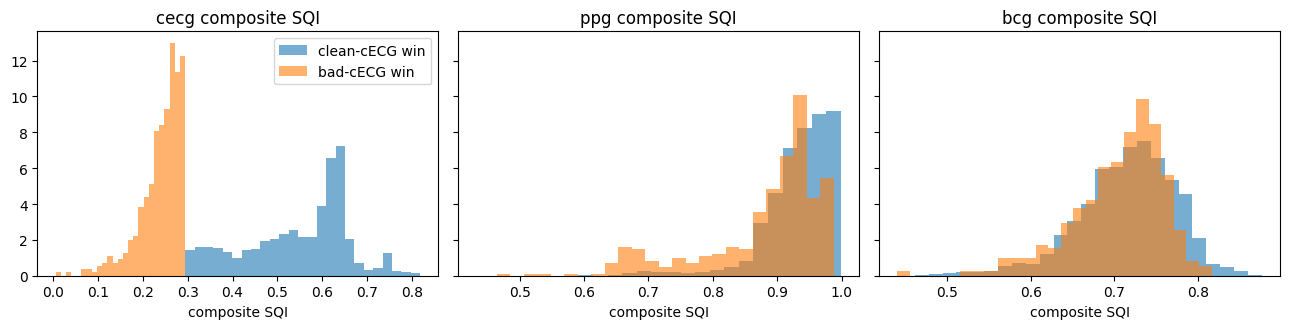

If the orange (bad-cECG) PPG/BCG distributions sit LEFT of blue, the other channels are degraded on the same windows -> no clean channel to route to -> reweighting cannot help.


In [2]:
bad = {m: COMP[:, j] <= np.quantile(COMP[:, j], BAD_Q) for j, m in enumerate(MODALITIES)}
badc = bad["cecg"]

rows = []
for j, m in enumerate(MODALITIES):
    auc_bad = roc_auc_score(y[badc], P[badc, j]) if len(np.unique(y[badc])) == 2 else np.nan
    auc_cln = roc_auc_score(y[~badc], P[~badc, j]) if len(np.unique(y[~badc])) == 2 else np.nan
    rows.append(dict(modality=m,
                     expert_AUC_badcECG=round(auc_bad, 3), expert_AUC_cleancECG=round(auc_cln, 3),
                     composite_badcECG=round(COMP[badc, j].mean(), 3),
                     composite_cleancECG=round(COMP[~badc, j].mean(), 3)))
display(pd.DataFrame(rows))

print(f"On bad-cECG windows (n={int(badc.sum())}):")
for m in ["ppg", "bcg"]:
    over = (badc & bad[m]).sum() / badc.sum()
    print(f"  fraction ALSO bad-{m}: {over:.2f}   (chance = {BAD_Q:.2f}  -> {over/BAD_Q:.1f}x)")

# visual: composite SQI distribution on bad-cECG vs clean-cECG, per modality
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4), sharey=True)
for j, m in enumerate(MODALITIES):
    ax[j].hist(COMP[~badc, j], bins=25, alpha=.6, label="clean-cECG win", density=True)
    ax[j].hist(COMP[badc, j],  bins=25, alpha=.6, label="bad-cECG win",  density=True)
    ax[j].set_title(f"{m} composite SQI"); ax[j].set_xlabel("composite SQI")
ax[0].legend(); plt.tight_layout(); plt.show()
print("If the orange (bad-cECG) PPG/BCG distributions sit LEFT of blue, the other channels are degraded "
      "on the same windows -> no clean channel to route to -> reweighting cannot help.")


## 3 · Abstention / risk-coverage — the honest job for the quality index here

If on the worst windows no channel is reliable, the right behaviour is **not to force a 0/1 call** but to
flag the window low-confidence. We rank windows by an *unsupervised* **decidability** score and report AUC on
the windows we keep (coverage). Two scores:

- **SQI decidability** = best available channel quality, `maxₘ compositeₘ` — "do we have *any* clean signal?"
  This is the quality index doing selective prediction, tying directly to the assignment.
- **prediction confidence** = `|p̂ − 0.5|` — a model-side baseline for comparison.

A rising AUC as coverage drops, together with the bad-cECG windows being shed first, is the evidence that the
quality index correctly knows *when not to trust the system* — a robustness contribution even though
reweighting was not.

Rank by SQI decidability (quality index decides when to abstain):


,coverage,AUC_covered,n_kept,frac_badcECG_kept
0,100%,0.902,4724,1.00
1,90%,0.920,4251,0.73
2,80%,0.936,3779,0.60
3,70%,0.965,3307,0.49
4,60%,0.981,2834,0.38
5,50%,0.987,2362,0.26


Rank by prediction confidence (baseline):


,coverage,AUC_covered,n_kept,frac_badcECG_kept
0,100%,0.902,4724,1.00
1,90%,0.916,4251,0.82
2,80%,0.929,3779,0.69
3,70%,0.940,3307,0.59
4,60%,0.949,2834,0.49
5,50%,0.961,2362,0.33


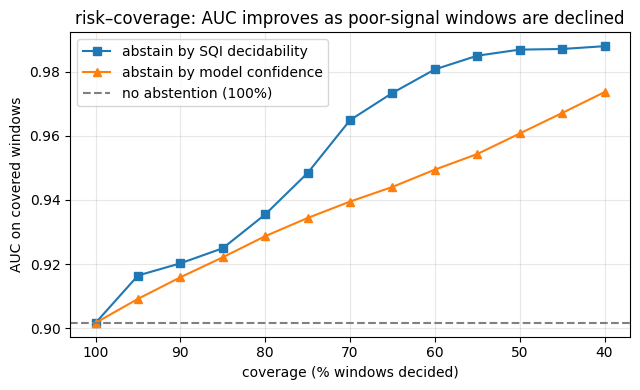

In [3]:
blend = sqi_weight_fuse(P, COMP)            # the deployed fusion (use your best one here)
decid_sqi  = COMP.max(1)                     # best available channel quality
decid_conf = np.abs(blend - 0.5)             # model confidence (comparison)

def risk_coverage(score, pred, y, badmask, covs=(1.0,.9,.8,.7,.6,.5)):
    out = []
    for cov in covs:
        thr = np.quantile(score, 1 - cov); keep = score >= thr
        ok = len(np.unique(y[keep])) == 2
        out.append(dict(coverage=f"{cov*100:.0f}%",
                        AUC_covered=round(roc_auc_score(y[keep], pred[keep]), 3) if ok else np.nan,
                        n_kept=int(keep.sum()),
                        frac_badcECG_kept=round((badmask & keep).sum() / max(badmask.sum(), 1), 2)))
    return pd.DataFrame(out)

print("Rank by SQI decidability (quality index decides when to abstain):")
rc_sqi = risk_coverage(decid_sqi, blend, y, badc); display(rc_sqi)
print("Rank by prediction confidence (baseline):")
rc_cnf = risk_coverage(decid_conf, blend, y, badc); display(rc_cnf)

covs = np.linspace(0.4, 1.0, 13)
def curve(score):
    a = []
    for cov in covs:
        keep = score >= np.quantile(score, 1 - cov)
        a.append(roc_auc_score(y[keep], blend[keep]) if len(np.unique(y[keep])) == 2 else np.nan)
    return a
plt.figure(figsize=(6.5, 4))
plt.plot(covs*100, curve(decid_sqi),  "s-", label="abstain by SQI decidability")
plt.plot(covs*100, curve(decid_conf), "^-", label="abstain by model confidence")
plt.axhline(roc_auc_score(y, blend), ls="--", c="grey", label="no abstention (100%)")
plt.xlabel("coverage (% windows decided)"); plt.ylabel("AUC on covered windows")
plt.title("risk–coverage: AUC improves as poor-signal windows are declined"); plt.legend(); plt.grid(alpha=.3)
plt.gca().invert_xaxis(); plt.tight_layout(); plt.show()


## 4 · What to write down

- **The quality index is valid.** It cleanly separates a high-performance regime (clean-cECG ≈0.92) from a
  failure regime (bad-cECG ≈0.69), and Section 2 shows it flags genuinely degraded windows.
- **Reweighting cannot rescue the failure regime, and Section 2 says why:** contactless artifacts co-occur
  across modalities (bad-cECG windows are several× more likely to be bad for PPG/BCG too, and those experts'
  AUCs drop there), so there is no reliable channel to up-weight. This is a *simultaneous-degradation*
  limit, not a routing-design flaw — a stronger, more interesting conclusion than a marginal AUC delta, and
  it explains every "ties-the-mean" result in the earlier notebooks.
- **The quality index's real robustness role is abstention.** Section 3's risk–coverage curve shows AUC on
  decided windows rising as the system declines poor-signal windows (which are exactly the bad-cECG ones),
  i.e. the index knows *when not to trust the fusion*. Report headline AUC at a chosen coverage (e.g. AUC at
  90% coverage) alongside full-coverage AUC.
- **For the algorithm comparison**, this becomes a second evaluation axis next to clean/patient-level
  metrics: selective-prediction AUC-vs-coverage per detector and per fusion rule.

> Tip: set `blend` in Section 3 to whichever fusion you report as primary (mean / SQI-weighted / gate); the
> abstention behaviour is a property of the *decidability score*, so it adds value on top of any of them.

In [4]:
hi_bcg = badc & (COMP[:,2] >= np.median(COMP[badc,2]))
print("BCG AUC on bad-cECG BUT clean-BCG windows:",
      round(roc_auc_score(y[hi_bcg], P[hi_bcg,2]), 3), "| n =", int(hi_bcg.sum()))

BCG AUC on bad-cECG BUT clean-BCG windows: 0.554 | n = 237
